In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\nihar\Desktop\Thesis - Sem 4\epl_final.csv")
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [3]:
df.shape

(9380, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9380 entries, 0 to 9379
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Season             9380 non-null   object
 1   MatchDate          9380 non-null   object
 2   HomeTeam           9380 non-null   object
 3   AwayTeam           9380 non-null   object
 4   FullTimeHomeGoals  9380 non-null   int64 
 5   FullTimeAwayGoals  9380 non-null   int64 
 6   FullTimeResult     9380 non-null   object
 7   HalfTimeHomeGoals  9380 non-null   int64 
 8   HalfTimeAwayGoals  9380 non-null   int64 
 9   HalfTimeResult     9380 non-null   object
 10  HomeShots          9380 non-null   int64 
 11  AwayShots          9380 non-null   int64 
 12  HomeShotsOnTarget  9380 non-null   int64 
 13  AwayShotsOnTarget  9380 non-null   int64 
 14  HomeCorners        9380 non-null   int64 
 15  AwayCorners        9380 non-null   int64 
 16  HomeFouls          9380 non-null   int64 


In [5]:
df.describe().round(2)

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00,9380.00
mean,1.54,1.18,0.69,0.52,13.62,10.81,5.97,4.69,6.04,4.77,11.28,11.77,1.47,1.79,0.06,0.09
std,1.31,1.16,0.84,0.74,5.36,4.70,3.27,2.75,3.11,2.75,3.75,3.92,1.22,1.29,0.25,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.00,10.00,7.00,4.00,3.00,4.00,3.00,9.00,9.00,1.00,1.00,0.00,0.00
50%,1.00,1.00,0.00,0.00,13.00,10.00,6.00,4.00,6.00,4.00,11.00,12.00,1.00,2.00,0.00,0.00
75%,2.00,2.00,1.00,1.00,17.00,14.00,8.00,6.00,8.00,6.00,14.00,14.00,2.00,3.00,0.00,0.00
max,9.00,9.00,5.00,5.00,43.00,37.00,24.00,20.00,20.00,19.00,33.00,29.00,7.00,9.00,3.00,2.00


In [6]:
df.isnull().sum()

Season               0
MatchDate            0
HomeTeam             0
AwayTeam             0
FullTimeHomeGoals    0
FullTimeAwayGoals    0
FullTimeResult       0
HalfTimeHomeGoals    0
HalfTimeAwayGoals    0
HalfTimeResult       0
HomeShots            0
AwayShots            0
HomeShotsOnTarget    0
AwayShotsOnTarget    0
HomeCorners          0
AwayCorners          0
HomeFouls            0
AwayFouls            0
HomeYellowCards      0
AwayYellowCards      0
HomeRedCards         0
AwayRedCards         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["MatchDate"] = pd.to_datetime(df["MatchDate"])
df["MatchDate"]

0      2000-08-19
1      2000-08-19
2      2000-08-19
3      2000-08-19
4      2000-08-19
          ...    
9375   2025-05-04
9376   2025-05-04
9377   2025-05-04
9378   2025-05-04
9379   2025-05-05
Name: MatchDate, Length: 9380, dtype: datetime64[ns]

In [9]:
result_labels = {"H":"Home Win", "D":"Draw", "A":"Away Win"}
outcome_counts = df["FullTimeResult"].value_counts()
outcome_counts = outcome_counts.rename(index=result_labels)

In [10]:
print("Match outcome counts:")
print(outcome_counts)
print("\nMatch outcome percentages:") 
print((outcome_counts / len(df) * 100).map(lambda x:f"{x:.2f}%"))

Match outcome counts:
FullTimeResult
Home Win    4299
Away Win    2768
Draw        2313
Name: count, dtype: int64

Match outcome percentages:
FullTimeResult
Home Win    45.83%
Away Win    29.51%
Draw        24.66%
Name: count, dtype: object


In [11]:
df["TotalGoals"] = (df["FullTimeHomeGoals"] + df["FullTimeAwayGoals"])
season_avg_goals = df.groupby("Season")["TotalGoals"].mean().reset_index()

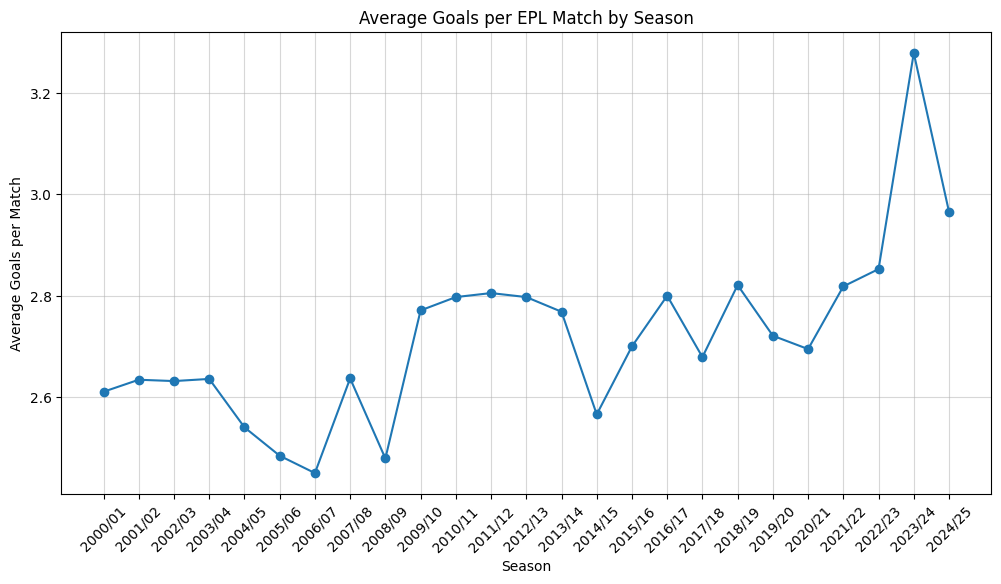

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(season_avg_goals["Season"], season_avg_goals["TotalGoals"], marker="o")
plt.title("Average Goals per EPL Match by Season")
plt.xlabel("Season")
plt.ylabel("Average Goals per Match")
plt.xticks(rotation=45)
plt.grid(alpha=0.5)
plt.show()

In [13]:
performance_by_result = (df.groupby("FullTimeResult")[[
    "FullTimeHomeGoals",
    "FullTimeAwayGoals",
    "HomeShots",
    "AwayShots",
    "HomeShotsOnTarget",
    "AwayShotsOnTarget",
    "HomeFouls",
    "AwayFouls"
]].mean().round(2))
performance_by_result = performance_by_result.rename(index={"H":"Home Win", "D":"Draw", "A":"Away Win"})
print(performance_by_result)

                FullTimeHomeGoals  FullTimeAwayGoals  HomeShots  AwayShots  \
FullTimeResult                                                               
Away Win                     0.57               2.32      12.00      12.56   
Draw                         1.01               1.01      13.31      10.81   
Home Win                     2.44               0.55      14.82       9.69   

                HomeShotsOnTarget  AwayShotsOnTarget  HomeFouls  AwayFouls  
FullTimeResult                                                              
Away Win                     4.63               6.02      11.35      11.45  
Draw                         5.52               4.56      11.54      12.10  
Home Win                     7.08               3.91      11.08      11.79  


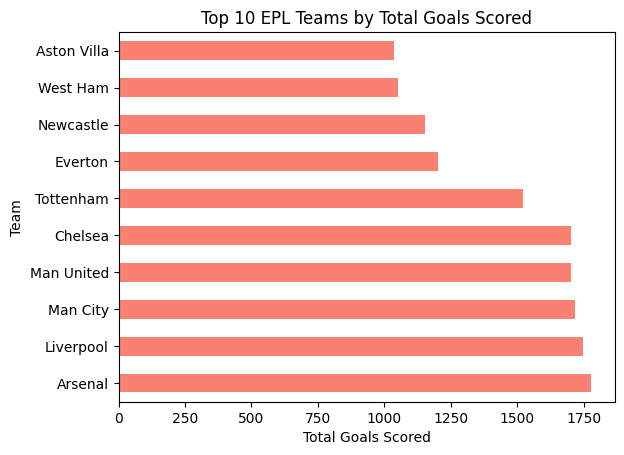

In [14]:
home_goals = df.groupby("HomeTeam")["FullTimeHomeGoals"].sum()
away_goals = df.groupby("AwayTeam")["FullTimeAwayGoals"].sum()
total_goals = home_goals.add(away_goals).sort_values(ascending=False)
total_goals.head(10).plot(kind="barh", color='salmon')
plt.title("Top 10 EPL Teams by Total Goals Scored")
plt.xlabel("Total Goals Scored")
plt.ylabel("Team")
plt.show()

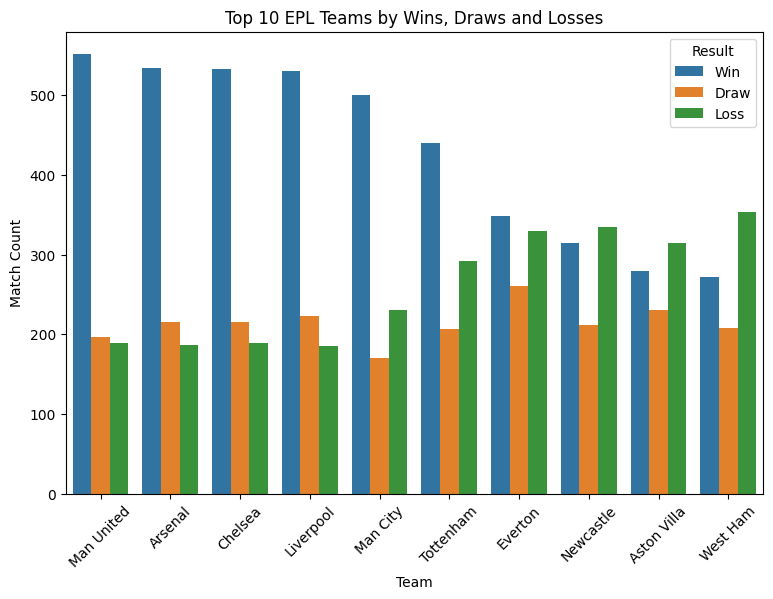

In [15]:
import seaborn as sns
home_results = pd.DataFrame({"Team": df["HomeTeam"],"Result": df["FullTimeResult"].map({"H": "Win","D": "Draw","A": "Loss"})})
away_results = pd.DataFrame({"Team": df["AwayTeam"],"Result": df["FullTimeResult"].map({"H": "Loss","D": "Draw","A": "Win"})})
team_results = pd.concat([home_results, away_results])
top_10 = (team_results[team_results["Result"] == "Win"]["Team"].value_counts().head(10).index)
top_10_results = team_results[team_results["Team"].isin(top_10)]
plt.figure(figsize=(9, 6))
sns.countplot(data=top_10_results, x="Team", hue="Result", order=top_10, hue_order=["Win", "Draw", "Loss"])
plt.title("Top 10 EPL Teams by Wins, Draws and Losses")
plt.xlabel("Team")
plt.ylabel("Match Count")
plt.xticks(rotation=45)
plt.show()

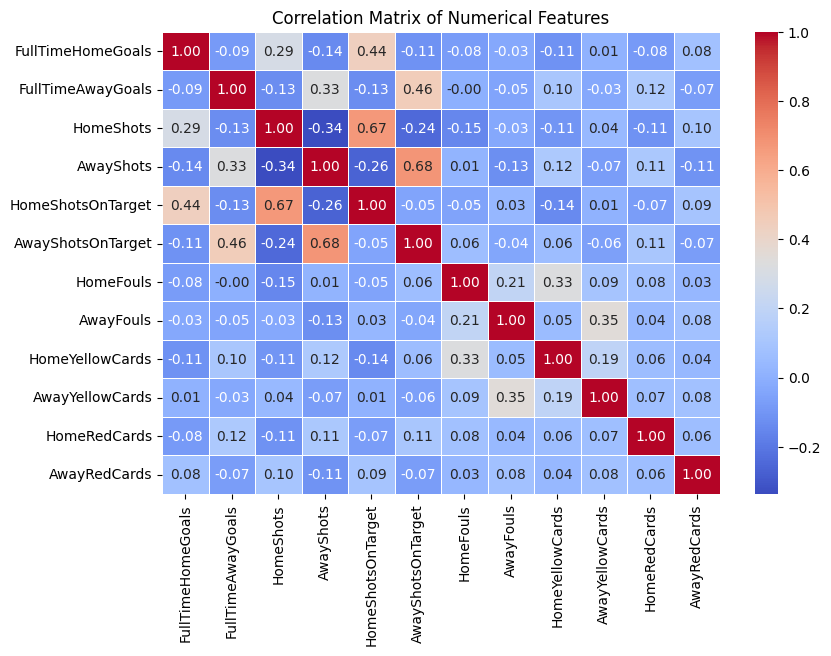

In [16]:
numeric_columns = ["FullTimeHomeGoals","FullTimeAwayGoals","HomeShots","AwayShots","HomeShotsOnTarget","AwayShotsOnTarget","HomeFouls","AwayFouls","HomeYellowCards","AwayYellowCards","HomeRedCards","AwayRedCards"]
corr_matrix = df[numeric_columns].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [17]:
home = pd.DataFrame({"Season": df["Season"],
    "Team": df["HomeTeam"],
    "GoalsScored": df["FullTimeHomeGoals"],
    "GoalsConceded": df["FullTimeAwayGoals"],
    "Points": df["FullTimeResult"].map({"H":3,"D":1,"A":0}),
    "Win": df["FullTimeResult"].map({"H":1,"D":0,"A":0})})

away = pd.DataFrame({"Season": df["Season"],
    "Team": df["AwayTeam"],
    "GoalsScored": df["FullTimeAwayGoals"],
    "GoalsConceded": df["FullTimeHomeGoals"],
    "Points": df["FullTimeResult"].map({"H":0,"D":1,"A":3}),
    "Win": df["FullTimeResult"].map({"H":0,"D":0,"A":1})})

team_data = pd.concat([home, away],ignore_index=True)
team_data.head()

,Season,Team,GoalsScored,GoalsConceded,Points,Win
0,2000/01,Charlton,4,0,3,1
1,2000/01,Chelsea,4,2,3,1
2,2000/01,Coventry,1,3,0,0
3,2000/01,Derby,2,2,1,0
4,2000/01,Leeds,2,0,3,1


In [18]:
season_stats = team_data.groupby(["Season", "Team"]).agg(
    Matches=("Points", "count"),
    TotalPoints=("Points", "sum"),
    AvgGoalsScored=("GoalsScored", "mean"),
    AvgGoalsConceded=("GoalsConceded", "mean"),
    WinRate=("Win", "mean")
).reset_index()

season_stats = season_stats.sort_values(["Team", "Season"]).reset_index(drop=True)
season_stats.head()

,Season,Team,Matches,TotalPoints,AvgGoalsScored,AvgGoalsConceded,WinRate
0,2000/01,Arsenal,38,70,1.657895,1.000000,0.526316
1,2001/02,Arsenal,38,87,2.078947,0.947368,0.684211
2,2002/03,Arsenal,38,78,2.236842,1.105263,0.605263
3,2003/04,Arsenal,33,77,1.848485,0.696970,0.666667
4,2004/05,Arsenal,33,71,2.212121,1.000000,0.636364


In [19]:
season_stats["PrevPoints"] = (season_stats.groupby("Team")["TotalPoints"].shift(1))
season_stats["PrevGoalsScored"] = (season_stats.groupby("Team")["AvgGoalsScored"].shift(1))
season_stats["PrevGoalsConceded"] = (season_stats.groupby("Team")["AvgGoalsConceded"].shift(1))
season_stats["PrevWinRate"] = (season_stats.groupby("Team")["WinRate"].shift(1))

model_df = season_stats.dropna(subset=["PrevPoints","PrevGoalsScored","PrevGoalsConceded","PrevWinRate"]).reset_index(drop=True)
model_df.head()

,Season,Team,Matches,TotalPoints,AvgGoalsScored,AvgGoalsConceded,WinRate,PrevPoints,PrevGoalsScored,PrevGoalsConceded,PrevWinRate
0,2001/02,Arsenal,38,87,2.078947,0.947368,0.684211,70.0,1.657895,1.000000,0.526316
1,2002/03,Arsenal,38,78,2.236842,1.105263,0.605263,87.0,2.078947,0.947368,0.684211
2,2003/04,Arsenal,33,77,1.848485,0.696970,0.666667,78.0,2.236842,1.105263,0.605263
3,2004/05,Arsenal,33,71,2.212121,1.000000,0.636364,77.0,1.848485,0.696970,0.666667
4,2005/06,Arsenal,38,67,1.789474,0.815789,0.526316,71.0,2.212121,1.000000,0.636364


In [20]:
from sklearn.model_selection import train_test_split
features = ["PrevPoints", "PrevGoalsScored", "PrevGoalsConceded", "PrevWinRate"]
X = model_df[features]
y = model_df["TotalPoints"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {"Linear Regression": LinearRegression(),
          "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
          "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
          "XGBoost": XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)}

for name, model in models.items(): model.fit(X_train, y_train)

In [22]:
predictions = {}
for name, model in models.items(): predictions[name] = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
results = []
for name in models:
    mae = mean_absolute_error(y_test, predictions[name])
    rmse = np.sqrt(mean_squared_error(y_test, predictions[name]))
    r2 = r2_score(y_test,predictions[name])
    results.append([name, mae, rmse, r2])
    results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
    results_df = results_df.sort_values("MAE").reset_index(drop=True)
    
results_df.round(3)

,Model,MAE,RMSE,R2
0,Linear Regression,9.366,11.429,0.533
1,XGBoost,10.050,12.465,0.444
2,Random Forest,10.083,12.547,0.437
3,Decision Tree,10.238,12.723,0.421


In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print("Best-performing model:", best_model_name)

best_model.fit(X, y)

Best-performing model: Linear Regression


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
forecast_data = season_stats[season_stats["Season"] == "2024/25"].copy()
relegated_teams = ["Ipswich", "Leicester", "Southampton"]
forecast_data = forecast_data[~forecast_data["Team"].isin(relegated_teams)].copy()
print("Teams available for 2025/26 forecast:",len(forecast_data))

Teams available for 2025/26 forecast: 17


In [25]:
X_2025_26 = forecast_data[["TotalPoints", "AvgGoalsScored", "AvgGoalsConceded", "WinRate"]].copy()
X_2025_26.columns = ["PrevPoints", "PrevGoalsScored", "PrevGoalsConceded", "PrevWinRate"]
X_2025_26.head()

,PrevPoints,PrevGoalsScored,PrevGoalsConceded,PrevWinRate
24,67,1.828571,0.885714,0.514286
46,60,1.571429,1.400000,0.485714
84,53,1.571429,1.200000,0.400000
89,52,1.771429,1.514286,0.428571
97,52,1.628571,1.600000,0.371429


In [26]:
forecast_data["PredictedPoints"] = (best_model.predict(X_2025_26).round(0))
forecast_table = forecast_data[["Team", "PredictedPoints"]].sort_values("PredictedPoints",ascending=False).reset_index(drop=True)
forecast_table["PredictedRank"] = (forecast_table.index + 1)
forecast_table = forecast_table[["PredictedRank", "Team", "PredictedPoints"]]

predicted_top6 = forecast_table.head(6).set_index("PredictedRank")
predicted_top6

,Team,PredictedPoints
PredictedRank,,
1,Liverpool,77.0
2,Arsenal,70.0
3,Man City,64.0
4,Chelsea,63.0
5,Newcastle,62.0
6,Bournemouth,58.0
